# SGRB $E_\text{peak}-E_\text{iso}$ relation
---

1. Read data (from `../data/nsns_population_joan.hdf5`)
2. Plot $E_\text{peak}-E_\text{iso}$ in logarithmic scale and marking the barycenter
3. Fit a linear regression to the logarithmic data and obtain best fit parameters for std-cosmology  using a chi-squared-test (also create plane figure)
4. Repeat the process through multiple cosmologies to find the best fit cosmology


In [8]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# 1. Read data
with h5py.File('../data/nsns_population_joan.hdf5', 'r') as table:
    print(table.keys())
    z = table['z'][()]
    Epeak = np.log10(table['Epeak'][()])
    Eiso = np.log10(table['Eiso'][()])
    dL = table['dL'][()]

# Create mask for rows with any NaN values
mask = np.isnan(z) | np.isnan(Epeak) | np.isnan(Eiso) | np.isnan(dL) | np.isinf(z) | np.isinf(Epeak) | np.isinf(Eiso) | np.isinf(dL)

# Apply mask to all arrays
z = z[~mask]
Epeak = Epeak[~mask]
Eiso = Eiso[~mask]
dL = dL[~mask]

<KeysViewHDF5 ['Eiso', 'Epeak', 'dL', 'deldL', 'det_KN', 'det_jet', 'iota', 'm1', 'm2', 'z']>


/var/folders/lq/7_q5kjhn1pzgzvpl0fk8y5mc0000gp/T/ipykernel_12778/1662726279.py:6: RuntimeWarning: divide by zero encountered in log10
  Eiso = np.log10(table['Eiso'][()])
/var/folders/lq/7_q5kjhn1pzgzvpl0fk8y5mc0000gp/T/ipykernel_12778/1662726279.py:6: RuntimeWarning: invalid value encountered in log10
  Eiso = np.log10(table['Eiso'][()])


In [10]:
for value in Eiso:
    if np.isinf(value): print('Hey')

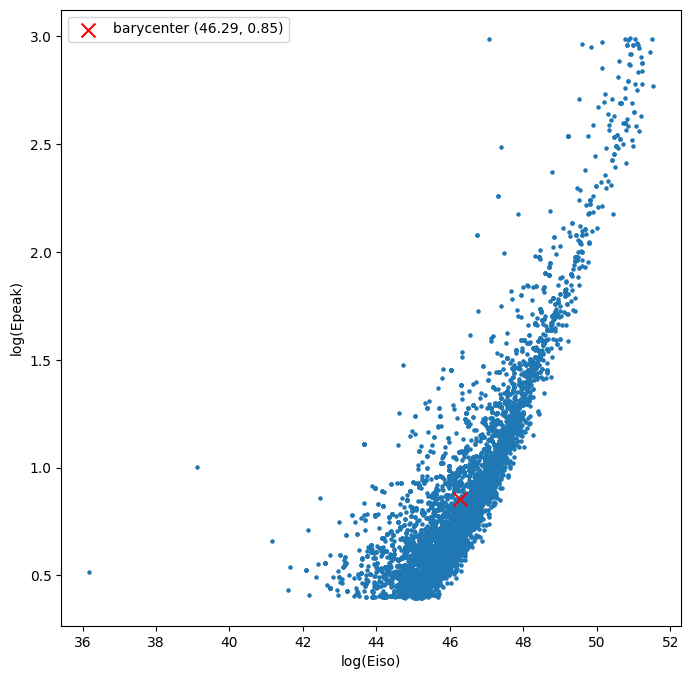

In [17]:
# 2. visualize data
plt.figure(figsize=(8,8))
plt.scatter(Eiso, Epeak, s=5)
plt.xlabel('log(Eiso)'); plt.ylabel('log(Epeak)')

# show data barycenter
plt.scatter(np.average(Eiso), np.average(Epeak), marker='x', c='r', s=100, label=f'barycenter ({np.average(Eiso):.2f}, {np.average(Epeak):.2f})')
plt.legend()

In [18]:
# Apply cut to data (only use first xth entries)
# mask = # apply redshift mask (maybe later)

z = z[50:]
Epeak = Epeak[50:]
Eiso = Eiso[50:]
dL = dL[50:]

0.273, 0.010


Text(0.5, 1.0, 'chi_surface of linear fit with standard cosmology')

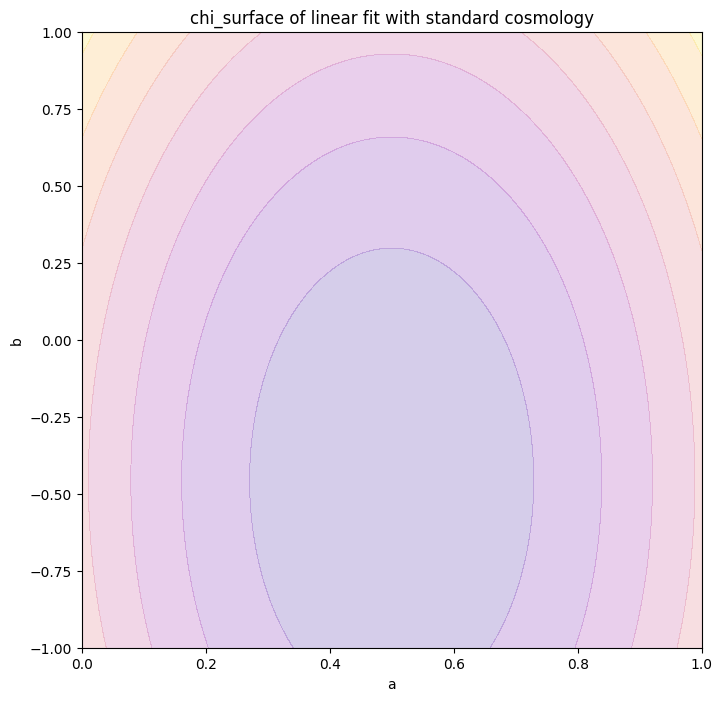

In [19]:
# 3. Fit linear regression with chi-squared-test using only standard cosmology (given dL)

def chi_squared(x, y, a, b):
    model = a*x + b
    chi2 = np.sum((y - model) ** 2)
    return chi2

Eiso_bc = Eiso - np.average(Eiso)
Epeak_bc = Epeak - np.average(Epeak)

a = np.linspace(0.0, 1.0, 100)
b = np.linspace(-1.0, 1.0, 100)
chi_surface = np.zeros([len(a), len(b)])
for i in range(len(a)):
    for j in range(len(b)):
        chi_surface[i,j] = chi_squared(Eiso_bc, Epeak_bc, a[i], b[j])

# find best fit values
min_chi = np.argmin(chi_surface)
idx = np.unravel_index(min_chi, chi_surface.shape)
a_min, b_min = a[idx[0]], b[idx[1]]
print(f'{a_min:.3f}, {b_min:.3f}')

plt.figure(figsize=(8,8))
plt.contourf(a, b, chi_surface, alpha=0.2, cmap='plasma')
plt.xlabel('a'); plt.ylabel('b'); plt.title('chi_surface of linear fit with standard cosmology')

### Next level: moving accros cosmologies fitting each parameter combination

In [7]:
import numpy as np
from astropy.cosmology import LambdaCDM
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from tqdm import tqdm
import h5py

with h5py.File('../data/nsns_population_joan.hdf5', 'r') as table:
    print(table.keys())
    z = table['z'][()]
    Epeak = np.log10(table['Epeak'][()])
    original_Eiso = np.log10(table['Eiso'][()])
    dL = table['dL'][()]


Om = np.linspace(0.0, 2.0, 50)
Ode = np.linspace(0.0, 2.0, 50)

#factor = 1.30
#extra_err = np.log10(factor)

standard_cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)
standard_dl = standard_cosmo.luminosity_distance(z)

chi_surface = np.zeros([len(Om), len(Ode)])
a = np.zeros([len(Om), len(Ode)])
b = np.zeros([len(Om), len(Ode)])
mask = np.zeros([len(Om), len(Ode)])

def model(x, p1, p2):
    return p1*x + p2


for i in tqdm(range(len(Om)), desc="Calculating χ² surface", leave=False):
    for j in range(len(Ode)):
        cosmo = LambdaCDM(H0=70, Om0=Om[i], Ode0=Ode[j])
        dl = cosmo.luminosity_distance(z)

        Eiso = 2*np.log10(dl/standard_dl) + original_Eiso
        Eiso_bc = Eiso - (np.sum(Eiso)/len(Eiso))

        if np.isnan(Eiso).any():
            a[i, j], b[i, j] = -1e4, -1e4
            chi_surface[i, j] = 1e4
            mask[i,j] = True
            continue

        #total_err = Epeak_err + extra_err

        popt, pcov = curve_fit(model, Eiso_bc, Epeak_bc, #sigma=total_err,
                               p0=[0.5, 0.0], bounds=([-10.0, -10.0], [10.0, 10.0]))
        a[i,j], b[i,j] = popt
        residuals = Epeak_bc - model(Eiso_bc, *popt)
        dof = len(Eiso_bc)-2
        #chi_surface[i, j] = np.sum((residuals / total_err) ** 2)#/dof
        chi_surface[i, j] = np.sum((residuals) ** 2)#/dof

masked_chi_surface = np.ma.array(chi_surface, mask=mask)

min_chi = np.nanmin(masked_chi_surface)
i1, i2 = np.unravel_index(np.nanargmin(masked_chi_surface), masked_chi_surface.shape)
Om_fit, Ode_fit = Om[i1], Ode[i2]

# Plotting
plt.figure()
#plt.contourf(Om, Ode, masked_chi_surface.T, levels=50)
plt.contour(Om, Ode, masked_chi_surface.T, levels=[min_chi+2.3, min_chi+4.61, min_chi+9.21], colors='r', alpha=[1.0, 0.75, 0.5], linestyles=['solid','dashed','dotted']) # 68, 95 and 99.7 percent confidence levels for two parameters
plt.scatter(Om_fit, Ode_fit, c='r', s=50, marker='x', label=f'Best fit: Om={Om_fit:.3f}, Ode={Ode_fit:.3f}, {min_chi:.3f}')
#plt.colorbar(label='chi2')
plt.scatter(0.3, 0.7, c='black', s=50, marker='x', label=f'Standard LCDM')
#plt.scatter(-1, -1, alpha=0.0, label=f'Extra factor: {extra_err:.3f}')
plt.xlim(0.0,2.0); plt.ylim(0.0, 2.0)
plt.xlabel('Om')
plt.ylabel('Ode')
plt.title(r'$\chi^2$ surface')
plt.legend()
plt.show()
plt.savefig('../figures/SGRBX2.png')

np.save('../data/SGRB_chi_surface.npy', chi_surface)
np.save('../data/SGRB_mask.npy', mask)

/var/folders/lq/7_q5kjhn1pzgzvpl0fk8y5mc0000gp/T/ipykernel_12778/2125240941.py:12: RuntimeWarning: divide by zero encountered in log10
  original_Eiso = np.log10(table['Eiso'][()])
/var/folders/lq/7_q5kjhn1pzgzvpl0fk8y5mc0000gp/T/ipykernel_12778/2125240941.py:12: RuntimeWarning: invalid value encountered in log10
  original_Eiso = np.log10(table['Eiso'][()])


<KeysViewHDF5 ['Eiso', 'Epeak', 'dL', 'deldL', 'det_KN', 'det_jet', 'iota', 'm1', 'm2', 'z']>


Calculating χ² surface:   0%|          | 0/50 [00:00<?, ?it/s]/Users/joanalnu/opt/anaconda3/envs/grbcosmo/lib/python3.13/site-packages/astropy/cosmology/_src/flrw/base.py:1179: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(self._inv_efunc_scalar, z1, z2, args=self._inv_efunc_scalar_args)[0]
/Users/joanalnu/opt/anaconda3/envs/grbcosmo/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2623: RuntimeWarning: invalid value encountered in _integral_comoving_distance_z1z2_scalar (vectorized)
  outputs = ufunc(*args, out=...)


KeyboardInterrupt: 